# 02 — H2 HEA / final relational payoff audit (human review)

Distinguishes lasting relational resolution from confession, apology, and ordinary repair.
Thin leaves `5.3a` and `8.3a` (one topic each) get exhaustive evidence packets — read them
in full below.

This notebook reads **saved** Pass A/B/C outputs only (no OpenRouter). Rating cells stay
blinded; narrative tertile on sentences is visible because H2 is position-aware.

The pool is small (lookup integrity expects **10** topics from `4.5` ∪ `5.3a` ∪ `8.3a`),
so every topic is close-read — nothing is sampled away.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh
from src.stage11_refined_construct_analysis.analysis import review_display as rd
from src.stage11_refined_construct_analysis.analysis.constructs import normalize_code
from src.stage11_refined_construct_analysis.lookup import load_topic_lookup, topics_for_leaves

ctx = nh.setup("02_h2_hea_payoff_audit")
cfg = ctx.cfg
HYP = "H2"
CODE_COL = "hea_code"

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/02_h2_hea_payoff_audit


## 1. The H2 pool — labels, not bare ids

Integrity trap: older docs said 11 topics; lookup must yield **10**.

In [2]:
lookup = load_topic_lookup(cfg)
h2_ids = topics_for_leaves(lookup, ["4.5", "5.3a", "8.3a"])
assert len(h2_ids) == int(cfg.section("integrity", "h2_expected_n_topics"))

master = nh.load_master(cfg)
h2 = master[master["topic_id"].isin(h2_ids)].copy()
h2["code_norm"] = h2[CODE_COL].map(normalize_code)

overview = rd.annotation_overview(h2, CODE_COL)
display(overview[["topic", "taxonomy", "code", "code_norm", "mixed", "agree"]])
ctx.save_table(overview, "hea_topic_overview_labeled")
ctx.save_table(h2, "hea_topic_annotations")

print("H2 pool (id — label):")
for line in rd.labeled_topic_list(lookup, h2_ids):
    print(f"  · {line}")

,topic,taxonomy,code,code_norm,mixed,agree
0,29 — Confessing Long-Held Love,"4.5 — Reconciliation, Commitments & HEA",HEA_CONFIRMED,None,False,
1,62 — Admitting You've Been Stupid,"4.5 — Reconciliation, Commitments & HEA",UNKNOWN,None,True,
2,65 — Declaring A True Partnership,"4.5 — Reconciliation, Commitments & HEA",HEA_CONFIRMED,None,True,H1
3,128 — Confessing How Much You've Missed,"4.5 — Reconciliation, Commitments & HEA",UNKNOWN,None,True,H1
4,157 — Swearing to Save Him From Himself,"4.5 — Reconciliation, Commitments & HEA",HEA_CONDITIONAL_TRAJECTORY,None,True,
5,204 — Promising to Care For Her Sister,"4.5 — Reconciliation, Commitments & HEA",CONDITIONAL_HEA — qualifies under 4.5 only if ...,None,False,
6,242 — Trading Forgiveness For Old Wrongs,"4.5 — Reconciliation, Commitments & HEA",UNKNOWN,None,False,"H1,H3"
7,305 — Confessing A Lifelong Regret,"4.5 — Reconciliation, Commitments & HEA",UNKNOWN,None,False,H1
8,167 — Planning A Wedding Reception,5.3a — Romantic Social Rituals & Public Couple...,HEA_PUBLIC_UNION,None,False,
9,61 — Planning to Exchange Rings,8.3a — Commitment Symbols & Love Tokens,HEA_CONFIRMED,None,True,


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/02_h2_hea_payoff_audit/tables/hea_topic_overview_labeled.csv  (10 rows)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/02_h2_hea_payoff_audit/tables/hea_topic_annotations.csv  (10 rows)
H2 pool (id — label):
  · 29 — Confessing Long-Held Love
  · 61 — Planning to Exchange Rings
  · 62 — Admitting You've Been Stupid
  · 65 — Declaring A True Partnership
  · 128 — Confessing How Much You've Missed
  · 157 — Swearing to Save Him From Himself
  · 167 — Planning A Wedding Reception
  · 204 — Promising to Care For Her Sister
  · 242 — Trading Forgiveness For Old Wrongs
  · 305 — Confessing A Lifelong Regret


## 2. Lexical vs contextual agreement + Pass C rationales

In [3]:
lex = nh.load_audit_jsonl(cfg, HYP, "A")
ctxu = nh.load_audit_jsonl(cfg, HYP, "B")
adj = nh.load_audit_jsonl(cfg, HYP, "C")
lex_idx = rd.audit_index(lex)
ctx_idx = rd.audit_index(ctxu)
adj_idx = rd.audit_index(adj)

agree = rd.agreement_table(h2, lex_idx, ctx_idx, adj_idx, hyp=HYP)
if not agree.empty:
    print(
        f"Lexical–contextual agreement: {agree['agree'].mean():.1%} "
        f"({int(agree['agree'].sum())}/{len(agree)})"
    )
    display(
        agree[
            [
                "topic",
                "taxonomy",
                "code_a",
                "code_b",
                "code_c",
                "agree",
                "action",
                "rationale_c",
            ]
        ]
    )
    ctx.save_table(agree, "h2_lexical_contextual_agreement")

Lexical–contextual agreement: 0.0% (0/10)


,topic,taxonomy,code_a,code_b,code_c,agree,action,rationale_c
0,29 — Confessing Long-Held Love,"4.5 — Reconciliation, Commitments & HEA",H2,H2_ILY_RECIPROCAL,HEA_CONFIRMED,False,CONFIRM,
1,61 — Planning to Exchange Rings,8.3a — Commitment Symbols & Love Tokens,H2,H2_EROTIC_ADORNMENT,HEA_CONFIRMED,False,CONFIRM_HEA,H2_EROTIC_ADORNMENT within taxonomy 8.3a signa...
2,62 — Admitting You've Been Stupid,"4.5 — Reconciliation, Commitments & HEA",H2,H2_NEGATIVE_SELF_OTHER_ASSESSMENT,UNKNOWN,False,,
3,65 — Declaring A True Partnership,"4.5 — Reconciliation, Commitments & HEA",H2,H2_ESTABLISHED_TOGETHERNESS,HEA_CONFIRMED,False,PASS_C,
4,128 — Confessing How Much You've Missed,"4.5 — Reconciliation, Commitments & HEA",H2,H2_MISS_REUNION_ROMANTIC,UNKNOWN,False,,
5,157 — Swearing to Save Him From Himself,"4.5 — Reconciliation, Commitments & HEA",H2,H2_NAME_INVOCATION,HEA_CONDITIONAL_TRAJECTORY,False,H2_NAME_INVOCATION in the second tertile with ...,
6,167 — Planning A Wedding Reception,5.3a — Romantic Social Rituals & Public Couple...,H2,H2_WEDDING_CEREMONY,HEA_PUBLIC_UNION,False,CONFIRM_HEA,H2_WEDDING_CEREMONY is a structurally definiti...
7,204 — Promising to Care For Her Sister,"4.5 — Reconciliation, Commitments & HEA",H1,H2_SIBLING_CONCERN,CONDITIONAL_HEA — qualifies under 4.5 only if ...,False,EVALUATE_HEA_VALIDITY,
8,242 — Trading Forgiveness For Old Wrongs,"4.5 — Reconciliation, Commitments & HEA",H2,H2_forgiveness_process_and_granting,UNKNOWN,False,,
9,305 — Confessing A Lifelong Regret,"4.5 — Reconciliation, Commitments & HEA",H2,H2_REGRET_PRESENT_ACTIVE,UNKNOWN,False,,


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/02_h2_hea_payoff_audit/tables/h2_lexical_contextual_agreement.csv  (10 rows)


## 3. Thin-leaf exhaustive check (`5.3a`, `8.3a`)

One topic each. If either is mostly generic confession / apology rather than final
relational payoff, the old composite HEA index was mis-measuring those leaves.

In [4]:
thin = h2[h2["current_taxonomy_id"].isin(["5.3a", "8.3a"])]
print("Thin HEA components — full cards follow in §4:")
display(
    thin.assign(
        topic=thin.apply(
            lambda r: rd.fmt_topic(r["topic_id"], r["current_topic_label"]), axis=1
        ),
        taxonomy=thin.apply(
            lambda r: rd.fmt_leaf(r["current_taxonomy_id"], r["current_taxonomy_name"]),
            axis=1,
        ),
    )[["topic", "taxonomy", "hea_code", "code_norm", "mixed_topic"]]
)
ctx.save_table(thin, "h2_thin_leaves")

Thin HEA components — full cards follow in §4:


,topic,taxonomy,hea_code,code_norm,mixed_topic
59,61 — Planning to Exchange Rings,8.3a — Commitment Symbols & Love Tokens,HEA_CONFIRMED,None,True
163,167 — Planning A Wedding Reception,5.3a — Romantic Social Rituals & Public Couple...,HEA_PUBLIC_UNION,None,False


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/02_h2_hea_payoff_audit/tables/h2_thin_leaves.csv  (2 rows)


## 4. Close reading — every H2 topic

What to look for: end-tertile sentences that settle the couple's status (commitment,
public union, lasting resolution) versus mid-book repair / "I'm sorry" / soft confession
that the old leaf labels would still have counted as HEA.

Close-reading 10 of 10 topics (disagreements / mixed / manual / stratified sample).

  TOPIC 29 — Confessing Long-Held Love
  Taxonomy : 4.5 — Reconciliation, Commitments & HEA
  Code     : HEA_CONFIRMED
  Stage08 snippets:
      · i love you with everything i am, everything i’ve been, and everything i hope to be
      · .” “
      · tell her i’ve always loved her.
      · i’ve always been in love with you.”
  Novel sentences:
    · [BOOK_001, CELL_B, tertile=end, p=0.80]
        I love you, too, sweetheart.”
    · [BOOK_001, CELL_B, tertile=end, p=0.76]
        Oh, child, I love you, too.”
    · [BOOK_001, CELL_B, tertile=end, p=0.74]
        You just say ‘I love you.’”
  Pass A/B/C:
    A lexical: H2
        All four representations converge on H2. The lexical profile combines romantic
        love vocabulary (love, loved, falling, always) with conflict and emotional
        processing terms (hated, forgive, crushed, spite, apologize, reflection) and no
        resolution or HEA payo

  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/02_h2_hea_payoff_audit/figures/h2_code_distribution.png


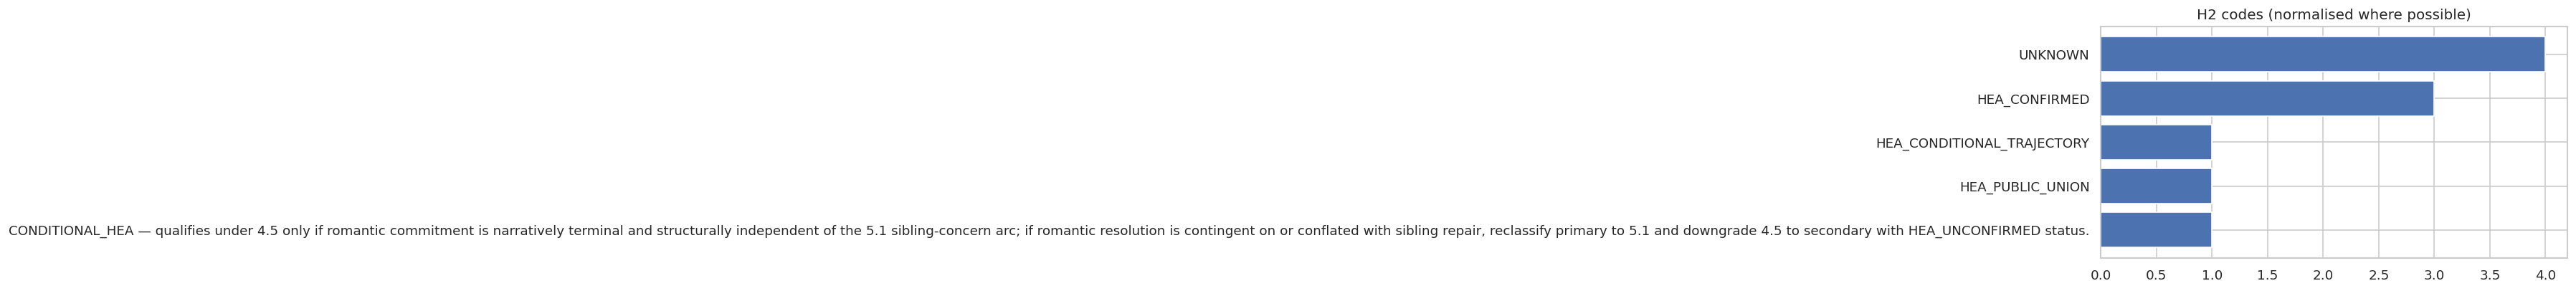

In [5]:
review_ids = rd.select_review_topics(
    h2,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    force_ids=thin["topic_id"].tolist(),
    show_all_if_n_le=12,
)
packs = rd.show_review_set(
    cfg,
    h2,
    review_ids,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    code_col=CODE_COL,
    max_sentences=12,
)
ctx.save_markdown(
    rd.render_review_markdown(packs, title="H2 HEA / payoff — close-reading pack"),
    "close_reading_pack",
)

fig, ax = plt.subplots(figsize=(7, 3.5))
vc = h2["code_norm"].fillna(h2[CODE_COL]).fillna("NULL").astype(str).value_counts()
ax.barh(vc.index[::-1], vc.values[::-1])
ax.set_title("H2 codes (normalised where possible)")
ctx.save_figure(fig, "h2_code_distribution")
plt.show()

### Atomic RAX carried forward

Later notebooks treat as separate atoms: repair, mutual_commitment, final_relational_payoff,
public_union, commitment_symbols, generic_confession_apology. A topic that reads as
apology-heavy should land on the last of those — not on final payoff.

print("H2 audit review complete. All pool topics close-read.")